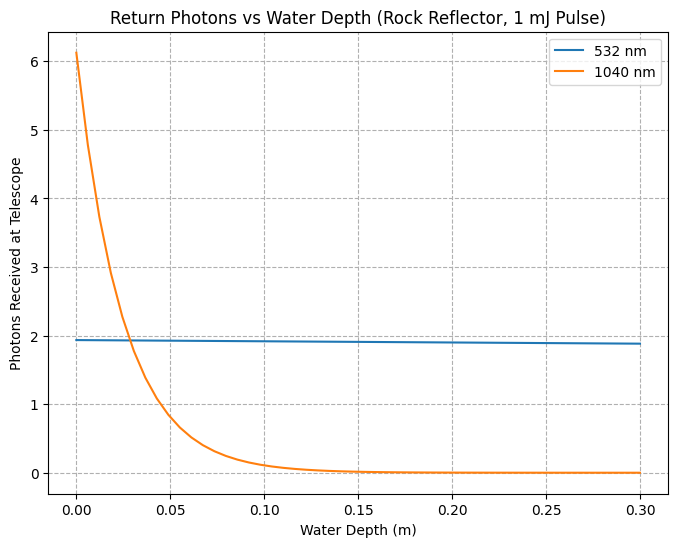

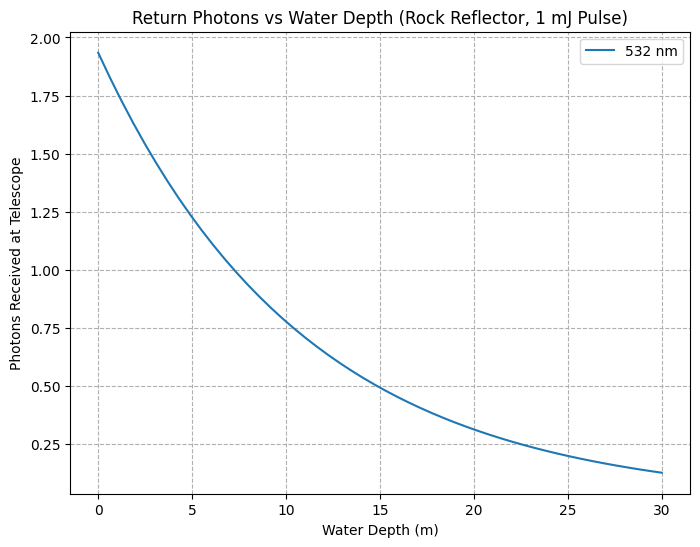

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
h = 6.626e-34       # Planck's constant (J·s)
c = 3e8             # speed of light (m/s)
depth_m = 0.3       # 1 ft water

# Laser parameters
pulse_energy = 1e-3  # J (1 mJ pulse)
divergence = 20e-6   # rad
orbit_altitude = 500e3  # 500 km

# Telescope parameters
D_telescope = 0.60        # m
A_telescope = np.pi * (D_telescope/2)**2

# Spot size on ground (fixed at 10m footprint for 20 µrad divergence)
spot_diameter = divergence * orbit_altitude
A_spot = np.pi * (spot_diameter/2)**2

# Coupling factor (telescope vs footprint)
coupling = A_telescope / A_spot

# Rock reflectance (%) at given wavelengths
reflectance = {
    532: 55.77/100,
    1040: 90.33/100
}

# Absorption coefficients (1/m) in water
absorption = {
    532: 0.045685518,
    1040: 20.22375538
}

# Function to compute photons received at telescope
def photons_received(wavelength_nm, depth_m):
    wavelength = wavelength_nm * 1e-9
    E_photon = h * c / wavelength  # photon energy (J)
    
    # Initial photons
    N0 = pulse_energy / E_photon
    
    # Water attenuation: Beer-Lambert (down + up path = 2*depth)
    alpha = absorption[wavelength_nm]
    transmittance = np.exp(-2 * alpha * depth_m)
    
    # Reflectance from rock
    refl = reflectance[wavelength_nm]
    
    # Photons back to telescope
    N_refl = N0 * refl * transmittance * coupling 
    N_received = N_refl * A_telescope / (np.pi * orbit_altitude**2)
    return N_received

# Depth sweep
depths = np.linspace(0, 0.3, 50)  # 0 → 1 ft
photons_532 = [photons_received(532, d) for d in depths]
photons_1040 = [photons_received(1040, d) for d in depths]

# Plot
plt.figure(figsize=(8,6))
plt.plot(depths, photons_532, label="532 nm")
plt.plot(depths, photons_1040, label="1040 nm")
plt.xlabel("Water Depth (m)")
plt.ylabel("Photons Received at Telescope")
plt.title("Return Photons vs Water Depth (Rock Reflector, 1 mJ Pulse)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# Depth sweep for 532nm
depths = np.linspace(0, 30, 50)  # 0 → 100 ft
photons_532 = [photons_received(532, d) for d in depths]
# Plot
plt.figure(figsize=(8,6))
plt.plot(depths, photons_532, label="532 nm")
plt.xlabel("Water Depth (m)")
plt.ylabel("Photons Received at Telescope")
plt.title("Return Photons vs Water Depth (Rock Reflector, 1 mJ Pulse)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()
